<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-9-Stochastically_Informed-NN/Untitled178.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Calibrating a Brownian Motion with Drift**

A fundamental stochastic differential equation is
$$
dX_t = \mu\, dt + \sigma\, dW_t.
$$
For simplicity, we assume that the drift $\mu$ and the volatility $\sigma$ are constants. In this case, the equation admits the explicit solution
$$
X_t = X_0 + \mu t + \sigma W_t,
$$
which is known as  *Brownian motion with drift*. This process is Gaussian, with
$$
X_t \sim \mathcal{N}(X_0 + \mu t, \, \sigma^2 t).
$$

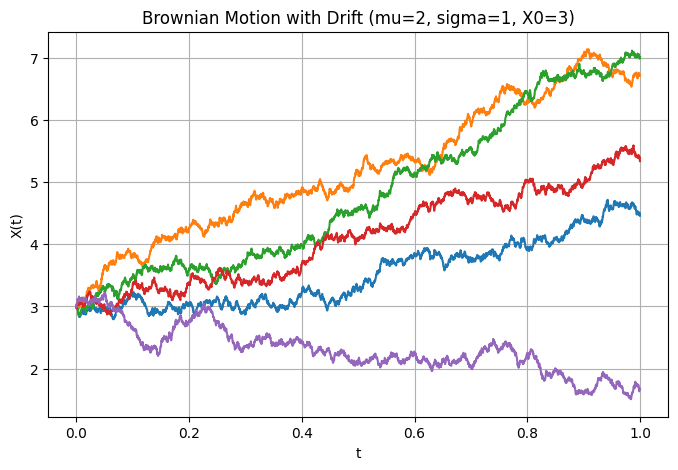

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================
mu = 2.0
sigma = 1.0
X0 = 3.0

T = 1.0
N = 3000               # time steps
dt = T / N

n_paths = 5           # number of realizations

t = np.linspace(0, T, N+1)

# =========================
# Simulation
# =========================
X = np.zeros((n_paths, N+1))
X[:, 0] = X0

for k in range(N):
    noise = np.random.randn(n_paths)
    X[:, k+1] = X[:, k] + mu * dt + sigma * np.sqrt(dt) * noise

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))

for i in range(n_paths):
    plt.plot(t, X[i], lw=1.5)

plt.title("Brownian Motion with Drift (mu=2, sigma=1, X0=3)")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.show()

Running an estimation of parameters $\mu$ and $\sigma$.

True parameters:
mu = 2.0, sigma = 1.0

Estimated parameters:
mu_hat    = 1.97027
sigma_hat = 0.99171


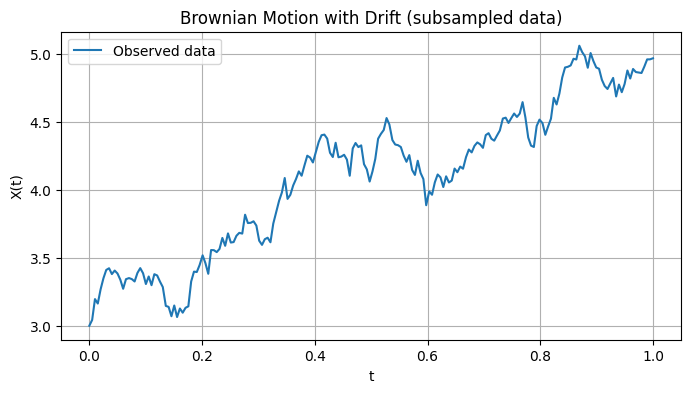

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# True parameters
# =========================
mu_true = 2.0
sigma_true = 1.0
X0 = 3.0

T = 1.0
N_total = 3000
dt = T / N_total

# =========================
# Simulate Brownian motion with drift
# =========================
X = np.zeros(N_total + 1)
X[0] = X0

for k in range(N_total):
    X[k+1] = X[k] + mu_true * dt + sigma_true * np.sqrt(dt) * np.random.randn()

# =========================
# Subsample n = 200 points
# =========================
n = 200
indices = np.linspace(0, N_total, n).astype(int)

t_data = indices * dt
X_data = X[indices]

# =========================
# Estimate mu (formula eq:musxx)
# =========================
mu_hat = (X_data[-1] - X_data[0]) / (t_data[-1] - t_data[0])

# =========================
# Estimate sigma (formula eq:sigma_BM)
# =========================
increments = X_data[1:] - X_data[:-1]

term1 = np.sum(increments**2)
term2 = (X_data[-1] - X_data[0])**2 / (n - 1)

sigma_hat = np.sqrt((term1 - term2) / (t_data[-1] - t_data[0]))

# =========================
# Output
# =========================
print("True parameters:")
print(f"mu = {mu_true}, sigma = {sigma_true}")

print("\nEstimated parameters:")
print(f"mu_hat    = {mu_hat:.5f}")
print(f"sigma_hat = {sigma_hat:.5f}")

# =========================
# Plot sampled trajectory
# =========================
plt.figure(figsize=(8,4))
plt.plot(t_data, X_data, label="Observed data")
plt.title("Brownian Motion with Drift (subsampled data)")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.legend()
plt.show()

Running 10,000 trials and construct histograms for $\mu$ and $\sigma$.

<>:70: SyntaxWarning: invalid escape sequence '\h'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\h'
<>:81: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\h'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\h'
<>:81: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3592/3931026820.py:70: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Distribution of $\hat{\mu}$")
/tmp/ipykernel_3592/3931026820.py:71: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")
/tmp/ipykernel_3592/3931026820.py:80: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Distribution of $\hat{\sigma}$")
/tmp/ipykernel_3592/3931026820.py:81: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sigma$")


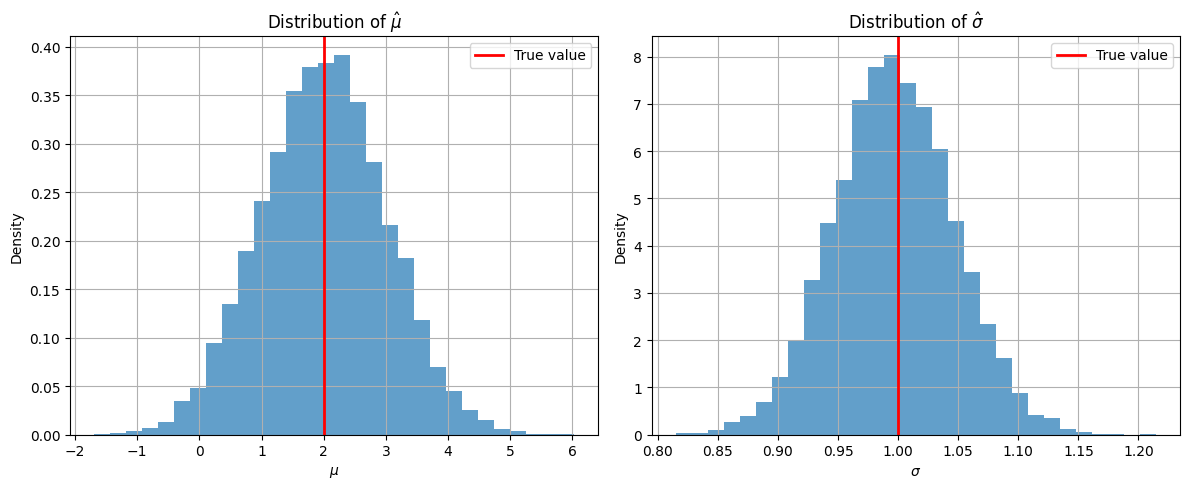

Mu:    mean = 2.0044344450822287 std = 1.0102466634195522
Sigma: mean = 0.9965168709261727 std = 0.049991576931804955


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# True parameters
# =========================
mu_true = 2.0
sigma_true = 1.0
X0 = 3.0

T = 1.0
N_total = 3000
dt = T / N_total

n = 200     # number of observations
M = 10000    # Monte Carlo runs

mu_estimates = []
sigma_estimates = []

for m in range(M):

    # =========================
    # Simulate BM with drift
    # =========================
    X = np.zeros(N_total + 1)
    X[0] = X0

    for k in range(N_total):
        X[k+1] = X[k] + mu_true * dt + sigma_true * np.sqrt(dt) * np.random.randn()

    # =========================
    # Subsample n = 200
    # =========================
    indices = np.linspace(0, N_total, n).astype(int)

    t_data = indices * dt
    X_data = X[indices]

    # =========================
    # Estimate mu
    # =========================
    mu_hat = (X_data[-1] - X_data[0]) / (t_data[-1] - t_data[0])

    # =========================
    # Estimate sigma
    # =========================
    increments = X_data[1:] - X_data[:-1]

    term1 = np.sum(increments**2)
    term2 = (X_data[-1] - X_data[0])**2 / (n - 1)

    sigma_hat = np.sqrt((term1 - term2) / (t_data[-1] - t_data[0]))

    mu_estimates.append(mu_hat)
    sigma_estimates.append(sigma_hat)

mu_estimates = np.array(mu_estimates)
sigma_estimates = np.array(sigma_estimates)

# =========================
# Plot histograms
# =========================
plt.figure(figsize=(12,5))

# ---- mu histogram
plt.subplot(1,2,1)
plt.hist(mu_estimates, bins=30, density=True, alpha=0.7)
plt.axvline(mu_true, color='red', linewidth=2, label="True value")
plt.title("Distribution of $\hat{\mu}$")
plt.xlabel("$\mu$")
plt.ylabel("Density")
plt.legend()
plt.grid()

# ---- sigma histogram
plt.subplot(1,2,2)
plt.hist(sigma_estimates, bins=30, density=True, alpha=0.7)
plt.axvline(sigma_true, color='red', linewidth=2, label="True value")
plt.title("Distribution of $\hat{\sigma}$")
plt.xlabel("$\sigma$")
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# =========================
# Summary statistics
# =========================
print("Mu:    mean =", np.mean(mu_estimates), "std =", np.std(mu_estimates))
print("Sigma: mean =", np.mean(sigma_estimates), "std =", np.std(sigma_estimates))